# 03 – Feature Engineering

## Load data

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd, re
from collections import Counter

data_dir = "/content/drive/MyDrive/resume-jd-matching/data"
train = pd.read_parquet(f"{data_dir}/train_clean.parquet")
val = pd.read_parquet(f"{data_dir}/val_clean.parquet")
test = pd.read_parquet(f"{data_dir}/test_clean.parquet")
print(train.shape, val.shape, test.shape)

Mounted at /content/drive
(5285, 3) (943, 3) (1759, 3)


## How skills appear in resumes

In [2]:
res = train["resume"].drop_duplicates()
jds = train["jd"].drop_duplicates()
print("Unique train resumes:", len(res), "| unique train JDs:", len(jds))
print("Resumes with a 'Skills' heading:", res.str.contains(r"\bSkills\b").mean().round(3))

for t in res.head(3):
    i = t.find("Skills")
    print("----\n", t[i:i + 400] if i >= 0 else "(no 'Skills' heading)")

Unique train resumes: 635 | unique train JDs: 240
Resumes with a 'Skills' heading: 0.825
----
 Skills: Public Speaking, Public Relations, Team Building, Project Management, Procedure writing, Staff Supervision and Management, Ability to interface with professionals on all levels. Accomplishments, Honors, and Activities -Board of Directors Member for the Food Bank of Corpus Christi from November 2010 to April 2013. -Held Life Insurance License -Basketball Official (Referee) High School Varsi
----
 Skills Guest services Inventory control procedures Merchandising expertise Loss prevention Cash register operations Product promotions Work History08/2012to Current Facilities Software Coordinator|City,STATE,Responsible for managing software across all products in Decatur IL, Joliet IL, and North Little Rock AR On-call 24 hours a day to provide support to field reps, assembly workers, and line sup
----
 Skills Diagnostics and troubleshooting OSHA requirements Electrical codes familiarity Safet

## Candidate skill phrases from training resumes

In [3]:
def phrases(t):
    out = set()
    for p in re.split(r"[,;•·|]", t):
        p = p.strip(" .:-()").lower()
        if 1 <= len(p.split()) <= 4 and 2 <= len(p) <= 40 and re.fullmatch(r"[a-z0-9+#./& -]+", p):
            out.add(p)
    return out

doc_freq = Counter(p for t in res for p in phrases(t))   # number of unique resumes containing each phrase
print("Candidate phrases:", len(doc_freq))
print("Appearing in at least 10 resumes:", sum(1 for c in doc_freq.values() if c >= 10))
print(pd.Series(doc_freq).sort_values(ascending=False).head(100).to_string())

Candidate phrases: 13193
Appearing in at least 10 resumes: 583
state                   397
ca                      176
excel                   167
sql                     141
reporting               132
database                125
documentation           121
clients                 115
processes               112
sales                   112
quality                 112
client                  109
powerpoint              107
access                  102
oracle                  101
c++                     101
java                    100
financial                95
inventory                94
tx                       93
word                     91
fl                       91
microsoft office         89
windows                  85
project management       84
office                   83
xml                      80
managing                 79
python                   78
payroll                  78
javascript               77
html                     77
research                 77
programming  

## Build the skill list
Mined phrases (≥10 train resumes) + seed skills → merge variants → drop noise → keep skills found in ≥3 train JDs.

In [4]:
US_STATES = set("al ak az ar ca co ct de fl ga hi id il in ia ks ky la me md ma mi mn ms mo mt ne nv nh nj "
                "nm ny nc nd oh ok or pa ri sc sd tn tx ut vt va wa wv wi wy dc".split())

GENERIC = {"state", "city", "inc", "llc", "usa", "company", "clients", "client", "processes", "process",
           "managing", "quality", "functional", "progress", "requirement", "requirements", "tables",
           "design", "designing", "delivery", "engineer", "materials", "meetings", "personnel",
           "enterprise", "policies", "office", "word", "access", "management", "team", "work",
           "skills", "experience", "summary", "education", "current", "various", "new"}

SEEDS = ["aws", "azure", "gcp", "docker", "kubernetes", "jenkins", "terraform", "git", "ci/cd",
         "machine learning", "deep learning", "data analysis", "data analytics", "statistics", "tableau",
         "power bi", "spark", "hadoop", "etl", "data warehouse", "big data", "pandas",
         "r programming", "scala", "golang", "ruby", "php", "react", "angular", "node.js", "rest api",
         "microservices", ".net", "spring", "postgresql", "mongodb", "nosql", "oracle database", "t-sql",
         "agile", "scrum", "jira", "sdlc", "itil", "six sigma", "lean", "salesforce", "crm", "erp", "sap",
         "workday", "peoplesoft", "forecasting", "budgeting", "auditing", "compliance", "risk management",
         "negotiation", "recruiting", "onboarding"]

ALIASES = {"ms office": "microsoft office", "ms excel": "excel", "microsoft excel": "excel",
           "ms word": "microsoft word", "ms access": "microsoft access", "ms powerpoint": "powerpoint",
           "microsoft powerpoint": "powerpoint", "ms sql server": "sql server",
           "microsoft sql server": "sql server", "postgres": "postgresql", "ms outlook": "outlook",
           "microsoft outlook": "outlook", "ms visio": "visio", "microsoft visio": "visio"}
           # Review round 1: extra noise and variants found in the first run
GENERIC |= {
    # generic words and verbs
    "development", "solutions", "benefits", "analysis", "develop", "financial", "system", "reports",
    "written", "monthly", "vision", "functions", "developing", "procedures", "operations", "fast",
    "organizational", "processing", "implementation", "balance", "focus", "equity", "features", "type",
    "quarterly", "next", "basic", "market", "approach", "vendors", "direction", "equipment", "government",
    "works", "automate", "content", "recording", "read", "filing", "agency", "developed", "english",
    "website", "protocols", "proposals", "view", "administrative", "utilities", "presenting", "logic",
    "switch", "checks", "implemented", "funds", "drawing", "receiving", "reading", "drivers",
    "installation", "strategic", "strategy", "real-time", "modeling", "closing", "analyzing", "profit",
    "year-end", "optimization", "workflow", "validation", "configuration", "upgrades", "migration",
    "integration", "servers", "senior management", "designed",
    # job titles
    "accountant", "software engineer", "developer", "analyst", "data analyst", "electrical engineer",
    "controller", "consultant", "director", "supervisor", "architect",
    # ambiguous short forms
    "ad", "ap", "san", "net", "com", "rest", "db", "win", "exchange",
    # everyday / office words
    "email", "phone", "mail", "telephone", "notes", "page", "forms", "charts", "video", "audio", "cable",
}

ALIASES.update({
    "test": "testing", "audits": "audit", "auditing": "audit", "budget": "budgeting", "budgets": "budgeting",
    "databases": "database", "troubleshoot": "troubleshooting", "network": "networking",
    "networks": "networking", "operating system": "operating systems",
    "data warehousing": "data warehouse", "financial reports": "financial reporting",
    "balance sheets": "balance sheet", "accrual": "accruals", "taxes": "tax", "mentor": "mentoring",
    "scripts": "scripting", "business process": "business processes", "problem-solving": "problem solving",
    "html5": "html", "css3": "css", "microsoft office suite": "microsoft office",
    "gl": "general ledger", "ledger": "general ledger", "bi": "business intelligence",
    "law": "legal", "hiring": "recruiting",
})

def pattern(term):
    # whole-term match that also works for c++, c#, .net, node.js
    return re.compile(r"(?<![a-z0-9])" + re.escape(term) + r"(?![a-z0-9])")

def count_docs(variants, docs):
    pats = [pattern(v) for v in variants]
    return sum(1 for d in docs if any(p.search(d) for p in pats))

# Rules 1 + 4: mined phrases (>=10 resumes) plus seeds; Rule 5: merge variants
mined = {p for p, c in doc_freq.items() if c >= 10}
candidates = {ALIASES.get(c, c) for c in mined | set(SEEDS)}

# Rule 3: drop noise (state codes, generic words, numbers, single characters)
candidates = {c for c in candidates
              if c not in US_STATES and c not in GENERIC
              and len(c) >= 2 and not re.fullmatch(r"[\d ./-]+", c)}

variants = {c: {c} | {v for v, k in ALIASES.items() if k == c} for c in candidates}

# Rule 2 (+ Rule 6 matching): keep skills found in >=3 train JDs
jd_low = [j.lower() for j in jds]
res_low = [r.lower() for r in res]
rows = []
for c in sorted(candidates):
    jd_n = count_docs(variants[c], jd_low)
    if jd_n >= 3:
        rows.append({"skill": c, "variants": "|".join(sorted(variants[c])),
                     "jd_count": jd_n, "resume_count": count_docs(variants[c], res_low)})

skills_df = pd.DataFrame(rows).sort_values("jd_count", ascending=False).reset_index(drop=True)
skills_df.to_csv(f"{data_dir}/skills.csv", index=False)

print("Final skills:", len(skills_df))
print("Seeds kept:", sorted(set(SEEDS) & set(skills_df["skill"])))
print("Seeds dropped (<3 JDs):", sorted(set(SEEDS) - set(skills_df["skill"])))
print("\nAll skills (most-requested first):\n")
print(", ".join(skills_df["skill"]))

Final skills: 203
Seeds kept: ['.net', 'agile', 'angular', 'aws', 'azure', 'big data', 'budgeting', 'compliance', 'crm', 'data analysis', 'data analytics', 'data warehouse', 'docker', 'erp', 'etl', 'forecasting', 'gcp', 'git', 'golang', 'hadoop', 'jenkins', 'jira', 'kubernetes', 'lean', 'machine learning', 'microservices', 'negotiation', 'node.js', 'nosql', 'onboarding', 'php', 'postgresql', 'power bi', 'react', 'recruiting', 'rest api', 'risk management', 'ruby', 'salesforce', 'sap', 'scala', 'scrum', 'sdlc', 'spark', 'spring', 'statistics', 'tableau', 'terraform', 'workday']
Seeds dropped (<3 JDs): ['auditing', 'ci/cd', 'deep learning', 'itil', 'mongodb', 'oracle database', 'pandas', 'peoplesoft', 'r programming', 'six sigma', 't-sql']

All skills (most-requested first):

accounting, testing, reporting, excel, finance, database, documentation, sql, insurance, problem solving, audit, legal, python, agile, architecture, recruiting, tax, training, compliance, general ledger, research, l

## Skill extraction

In [5]:
SKILL_PATTERNS = {
    row.skill: re.compile(r"(?<![a-z0-9])(?:" + "|".join(re.escape(v) for v in row.variants.split("|")) + r")(?![a-z0-9])")
    for row in skills_df.itertuples()
}

def extract_skills(text):
    t = text.lower()
    return {s for s, p in SKILL_PATTERNS.items() if p.search(t)}

jd_sk = extract_skills(train.loc[0, "jd"])
res_sk = extract_skills(train.loc[0, "resume"])
print("Label:", train.loc[0, "label"])
print("JD skills:", sorted(jd_sk))
print("Resume skills:", sorted(res_sk))
print("Matched:", sorted(jd_sk & res_sk))
print("Missing:", sorted(jd_sk - res_sk))

Label: No Fit
JD skills: ['accounting', 'banking', 'change management', 'credit', 'database', 'excel', 'finance', 'leadership', 'legal', 'risk management', 'sql', 'test cases', 'testing', 'training']
Resume skills: ['accounting', 'accounting software', 'accounts payable', 'accounts receivable', 'audit', 'balance sheet', 'billing', 'budgeting', 'contracts', 'cpa', 'credit', 'customer service', 'excel', 'fixed assets', 'forecasting', 'general ledger', 'hr', 'insurance', 'inventory', 'maintenance', 'microsoft office', 'networking', 'payroll', 'planning', 'project management', 'quality assurance', 'reporting', 'retail', 'safety', 'sales', 'shipping', 'supervision', 'tax', 'training', 'troubleshooting', 'windows']
Matched: ['accounting', 'credit', 'excel', 'training']
Missing: ['banking', 'change management', 'database', 'finance', 'leadership', 'legal', 'risk management', 'sql', 'test cases', 'testing']


## Skill features

In [6]:
# Extract once per unique text (texts repeat a lot), then map back to rows
all_texts = pd.concat([d[c] for d in (train, val, test) for c in ("jd", "resume")]).drop_duplicates()
skill_cache = {t: extract_skills(t) for t in all_texts}
print("Unique texts processed:", len(skill_cache))

def add_skill_features(df):
    df = df.copy()
    jd_s = df["jd"].map(skill_cache)
    res_s = df["resume"].map(skill_cache)
    matched = [j & r for j, r in zip(jd_s, res_s)]
    missing = [j - r for j, r in zip(jd_s, res_s)]
    df["jd_skill_count"] = jd_s.map(len)
    df["resume_skill_count"] = res_s.map(len)
    df["matched_count"] = [len(m) for m in matched]
    df["missing_count"] = [len(m) for m in missing]
    df["skill_coverage"] = [len(m) / len(j) if j else 0.0 for m, j in zip(matched, jd_s)]
    df["skill_jaccard"] = [len(j & r) / len(j | r) if (j | r) else 0.0 for j, r in zip(jd_s, res_s)]
    df["matched_skills"] = ["|".join(sorted(m)) for m in matched]
    df["missing_skills"] = ["|".join(sorted(m)) for m in missing]
    return df

train_f, val_f, test_f = (add_skill_features(d) for d in (train, val, test))

order = ["No Fit", "Potential Fit", "Good Fit"]
num_cols = ["jd_skill_count", "resume_skill_count", "matched_count", "missing_count", "skill_coverage", "skill_jaccard"]
print("\nMedian by label (train):")
print(train_f.groupby("label")[num_cols].median().loc[order].round(3).to_string())
print("\nJDs with 0 skills found:", (train_f.drop_duplicates("jd")["jd_skill_count"] == 0).sum(), "of", train_f["jd"].nunique())

Unique texts processed: 994

Median by label (train):
               jd_skill_count  resume_skill_count  matched_count  missing_count  skill_coverage  skill_jaccard
label                                                                                                         
No Fit                   11.0                24.0            2.0            8.0           0.200          0.061
Potential Fit            10.0                24.0            3.0            7.0           0.286          0.094
Good Fit                 13.0                27.0            3.0            8.0           0.280          0.095

JDs with 0 skills found: 1 of 240


## Skill coverage chart and save

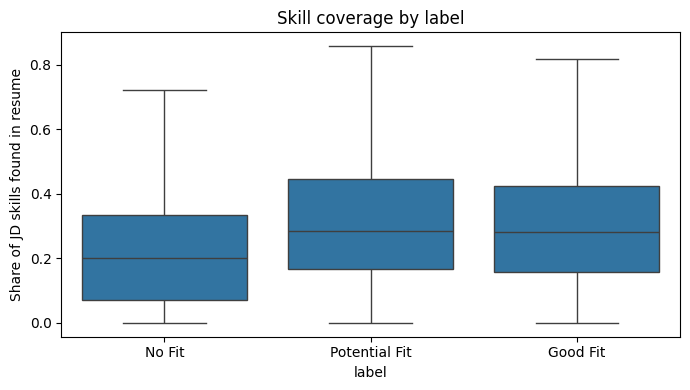

Saved: (5285, 11) (943, 11) (1759, 11)


In [7]:
import matplotlib.pyplot as plt, seaborn as sns, os
fig_dir = "/content/drive/MyDrive/resume-jd-matching/reports/figures"
os.makedirs(fig_dir, exist_ok=True)

plt.figure(figsize=(7, 4))
sns.boxplot(data=train_f, x="label", y="skill_coverage", order=order, showfliers=False)
plt.ylabel("Share of JD skills found in resume"); plt.title("Skill coverage by label")
plt.tight_layout(); plt.savefig(f"{fig_dir}/05_skill_coverage.png", dpi=150); plt.show()

train_f.to_parquet(f"{data_dir}/train_feat.parquet", index=False)
val_f.to_parquet(f"{data_dir}/val_feat.parquet", index=False)
test_f.to_parquet(f"{data_dir}/test_feat.parquet", index=False)
print("Saved:", train_f.shape, val_f.shape, test_f.shape)

## Skill feature findings
- Skill coverage (median): No Fit 0.200, Potential Fit 0.286, Good Fit 0.280.
- Skills separate No Fit from the other labels more clearly than word overlap (~40% vs ~21% rise).
- Skills do not separate Potential Fit from Good Fit; other signals (experience, embeddings) are needed.
- Only 1 of 240 train JDs has no skills from the list.

## How experience appears in JDs and resumes

In [8]:
def ctx(t, pat, w=40, n=3):
    return [t[max(0, m.start() - w):m.end() + w].replace("\n", " ")
            for m in list(re.finditer(pat, t, flags=re.I))[:n]]

YEARS = r"\b\d{1,2}\s*\+?\s*(?:-|to)?\s*\d{0,2}\s*\+?\s*(?:years?|yrs?)\b"
MMYYYY = r"\b(?:0?[1-9]|1[0-2])/(?:19|20)\d{2}\b"
MONTH_YEAR = r"\b(?:jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec)[a-z]*\.?\s+(?:19|20)\d{2}\b"
CURRENT = r"\b(?:current|present)\b"

jd_u = train_f.drop_duplicates("jd")["jd"]
res_u = train_f.drop_duplicates("resume")["resume"]

print("JDs mentioning 'N years':", f"{jd_u.str.contains(YEARS, case=False).mean():.1%}")
for t in jd_u.head(40):
    c = ctx(t, YEARS, n=1)
    if c: print("  JD:", c[0])

print("\nResumes with:")
for name, pat in [("'N years'", YEARS), ("MM/YYYY dates", MMYYYY), ("Month YYYY dates", MONTH_YEAR),
                  ("'Current/Present'", CURRENT)]:
    print(f"  {name}: {res_u.str.contains(pat, case=False).mean():.1%}")

for t in res_u.head(5):
    print("\n  RESUME dates:", ctx(t, MMYYYY + "|" + MONTH_YEAR, w=25, n=4))
    print("  RESUME years:", ctx(t, YEARS, w=30, n=2))

JDs mentioning 'N years': 70.4%
  JD:  accelerated growth of 300% in the last 3 years with over 5500+ employees globally, wit
  JD: eferred targeted graduation date within 1 year (preferred). Will consider interns who 
  JD: er Engineering, or equivalent.Typically 6+ years experience in one or more of the follow
  JD: icrosoft Office Suite, and have a 2- or 4-year degree, or equivalent experience. To be
  JD: s 3. Gitlab Target Years of Experience: 0-2 years Other relevant software development Mus
  JD: tform teams What you will need to have: 15+ years of experience in software engineering r
  JD: rtified Public Accountant with at lease 3 years of professional accounting or finance e
  JD: quired.CPA license preferred.Minimum of 3+ years of tax accounting experience.Public com
  JD: his Role Requirements Analysis At least 5 years of experience and use cases with the fo
  JD: ree or equivalent practical experience. 2 years of experience with software development
  JD:  this role if you 

## Experience features
JD: required years (only near "experience" or after "minimum/at least"; ranges use the lower number; several → highest).
Resume: span of job date ranges; "Current" = latest year in that resume; years outside 1960–2025 ignored.

In [9]:
import numpy as np

# ---------- JD required years (rules 1-3) ----------
YRS = r"(\d{1,2})\s*\+?\s*(?:(?:-|to)\s*\d{1,2}\s*\+?\s*)?(?:years?|yrs?)\b"
MIN_YRS = re.compile(r"(?:minimum(?: of)?|at least|min\.?)\s*" + YRS)
ANY_YRS = re.compile(YRS)

def jd_years(text):
    t = text.lower()
    found = [int(m.group(1)) for m in MIN_YRS.finditer(t)]
    for m in ANY_YRS.finditer(t):
        window = t[max(0, m.start() - 40):m.end() + 40]
        if "experience" in window:
            found.append(int(m.group(1)))          # group 1 = lower number of a range
    found = [y for y in found if 0 <= y <= 30]
    return max(found) if found else np.nan        # rule 3: highest requirement

# ---------- Resume years from job date ranges (rules 4-6) ----------
MONTHS = r"(?:jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec)[a-z]*\.?"
DATE = rf"(?<!\d)(?:(?:0?[1-9]|1[0-2])/|{MONTHS}\s+)?((?:19|20)\d{{2}})(?!\d)"
RANGE = re.compile(rf"{DATE}\s*(?:-|to)\s*(?:{DATE}|(current|present|now))")

def resume_years(text):
    t = text.lower()
    ranges = []
    for m in RANGE.finditer(t):
        start = int(m.group(1))
        end = int(m.group(2)) if m.group(2) else None      # None = Current/Present
        if not 1960 <= start <= 2025:                      # rule 6
            continue
        if end is not None and (not 1960 <= end <= 2025 or end < start):
            continue
        ranges.append((start, end))
    if not ranges:
        return np.nan
    latest = max([s for s, _ in ranges] + [e for _, e in ranges if e])   # rule 5
    return float(max(e if e else latest for _, e in ranges) - min(s for s, _ in ranges))

# ---------- Tests (from real text seen in Cell 8) ----------
print(jd_years("Typically 6+ years experience in one or more of the following"))         # 6
print(jd_years("accelerated growth of 300% in the last 3 years with over 5500+ employees"))  # nan
print(jd_years("have a 2- or 4-year degree, or equivalent experience"))                  # nan
print(jd_years("Key Experience:7+ years accounting experience4+ years as a senior"))     # 7
print(jd_years("Minimum of 3+ years of tax accounting experience"))                      # 3
print(resume_years("Accountant,08/2014-05/2015 Aspirus Manager,02/2014-06/2014 Tradeweb"))  # 1.0
print(resume_years("from November 2010 to April 2013. Accountant,04/2017-Current"))       # 7.0
print(resume_years("Accountant,01/1920-06/2017 ... Accountant,04/2017-Current"))          # 0.0

6
nan
nan
7
3
1.0
7.0
0.0


In [10]:
exp_cache = {}
for d in (train_f, val_f, test_f):
    for t in d["jd"].unique():
        exp_cache.setdefault(("jd", t), jd_years(t))
    for t in d["resume"].unique():
        exp_cache.setdefault(("res", t), resume_years(t))

def add_exp_features(df):
    df = df.copy()
    df["jd_years"] = df["jd"].map(lambda t: exp_cache[("jd", t)])
    df["resume_years"] = df["resume"].map(lambda t: exp_cache[("res", t)])
    df["jd_years_missing"] = df["jd_years"].isna().astype(int)
    df["resume_years_missing"] = df["resume_years"].isna().astype(int)
    df["exp_gap"] = df["resume_years"] - df["jd_years"]
    df["exp_meets"] = np.where(df["exp_gap"].isna(), np.nan, (df["exp_gap"] >= 0).astype(float))
    return df

train_f, val_f, test_f = (add_exp_features(d) for d in (train_f, val_f, test_f))

print("Found years in unique JDs:", f"{train_f.drop_duplicates('jd')['jd_years'].notna().mean():.1%}")
print("Found years in unique resumes:", f"{train_f.drop_duplicates('resume')['resume_years'].notna().mean():.1%}")
print("Rows with both (exp_gap available):", f"{train_f['exp_gap'].notna().mean():.1%}")

print("\nBy label (train, rows where available):")
print(train_f.groupby("label").agg(jd_years=("jd_years", "median"),
                                   resume_years=("resume_years", "median"),
                                   exp_gap=("exp_gap", "median"),
                                   exp_meets_rate=("exp_meets", "mean")).loc[order].round(2).to_string())

train_f.to_parquet(f"{data_dir}/train_feat.parquet", index=False)
val_f.to_parquet(f"{data_dir}/val_feat.parquet", index=False)
test_f.to_parquet(f"{data_dir}/test_feat.parquet", index=False)
print("\nSaved:", train_f.shape, val_f.shape, test_f.shape)

Found years in unique JDs: 69.2%
Found years in unique resumes: 98.3%
Rows with both (exp_gap available): 70.0%

By label (train, rows where available):
               jd_years  resume_years  exp_gap  exp_meets_rate
label                                                         
No Fit              6.0           6.0     -1.0            0.50
Potential Fit       5.0           6.0      0.0            0.59
Good Fit            6.0           6.0      0.0            0.54

Saved: (5285, 17) (943, 17) (1759, 17)


## Experience feature findings

### Resume experience check
Confirm resume experience estimates are realistic (median 8 years, max 48).

In [11]:
print(train_f.drop_duplicates("resume")["resume_years"].describe().round(1))

count    624.0
mean       9.4
std        6.1
min        0.0
25%        5.0
50%        8.0
75%       13.0
max       48.0
Name: resume_years, dtype: float64


## Text similarity features
TF-IDF cosine (keywords, fitted on train only) and Sentence-BERT embedding cosine (meaning; long texts split into chunks and averaged).

In [12]:
!pip install -q sentence-transformers
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd, numpy as np, re, torch, joblib, os
data_dir = "/content/drive/MyDrive/resume-jd-matching/data"
model_dir = "/content/drive/MyDrive/resume-jd-matching/models"
os.makedirs(model_dir, exist_ok=True)

train_f = pd.read_parquet(f"{data_dir}/train_feat.parquet")
val_f = pd.read_parquet(f"{data_dir}/val_feat.parquet")
test_f = pd.read_parquet(f"{data_dir}/test_feat.parquet")
order = ["No Fit", "Potential Fit", "Good Fit"]
print(train_f.shape, val_f.shape, test_f.shape, "| GPU:", torch.cuda.is_available())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(5285, 17) (943, 17) (1759, 17) | GPU: True


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(ngram_range=(1, 2), stop_words="english", min_df=2, sublinear_tf=True)
fit_texts = pd.concat([train_f["jd"], train_f["resume"]]).drop_duplicates()   # train only
tfidf.fit(fit_texts)
print("Fitted on", len(fit_texts), "train texts | vocabulary:", len(tfidf.vocabulary_))

def tfidf_cos(df):
    J, R = tfidf.transform(df["jd"]), tfidf.transform(df["resume"])
    return np.asarray(J.multiply(R).sum(axis=1)).ravel()   # vectors are L2-normalised, so dot = cosine

for d in (train_f, val_f, test_f):
    d["tfidf_cosine"] = tfidf_cos(d)

joblib.dump(tfidf, f"{model_dir}/tfidf_vectorizer.joblib")   # reused by the app
print(train_f.groupby("label")["tfidf_cosine"].median().loc[order].round(3))

Fitted on 875 train texts | vocabulary: 75675
label
No Fit           0.026
Potential Fit    0.034
Good Fit         0.037
Name: tfidf_cosine, dtype: float64


In [14]:
from sentence_transformers import SentenceTransformer

sbert = SentenceTransformer("all-MiniLM-L6-v2", device="cuda" if torch.cuda.is_available() else "cpu")
CHUNK = 180   # ~180 words ≈ 230-250 tokens, within the model's 256-token limit

def chunks(text):
    w = text.split()
    return [" ".join(w[i:i + CHUNK]) for i in range(0, len(w), CHUNK)] or [""]

texts = pd.concat([d[c] for d in (train_f, val_f, test_f) for c in ("jd", "resume")]).drop_duplicates().tolist()
all_chunks, owner = [], []
for i, t in enumerate(texts):
    for c in chunks(t):
        all_chunks.append(c); owner.append(i)
print("Texts:", len(texts), "| chunks:", len(all_chunks))

E = sbert.encode(all_chunks, batch_size=64, show_progress_bar=True, normalize_embeddings=True)
doc = np.zeros((len(texts), E.shape[1]), dtype=np.float32)
np.add.at(doc, np.array(owner), E)                         # sum chunk vectors per text
doc /= np.linalg.norm(doc, axis=1, keepdims=True)          # average direction, unit length
emb = dict(zip(texts, doc))

for d in (train_f, val_f, test_f):
    d["embed_cosine"] = [float(emb[j] @ emb[r]) for j, r in zip(d["jd"], d["resume"])]

joblib.dump({"texts": texts, "embeddings": doc}, f"{data_dir}/embeddings.joblib")
print(train_f.groupby("label")["embed_cosine"].median().loc[order].round(3))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Texts: 994 | chunks: 3911


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

label
No Fit           0.441
Potential Fit    0.495
Good Fit         0.510
Name: embed_cosine, dtype: float64


## Feature comparison
Rank all features by Spearman correlation with the label, then save.

In [15]:
lab = train_f["label"].map({"No Fit": 0, "Potential Fit": 1, "Good Fit": 2})
feat_cols = ["skill_coverage", "skill_jaccard", "matched_count", "missing_count", "jd_skill_count",
             "resume_skill_count", "jd_years", "resume_years", "exp_gap", "exp_meets",
             "tfidf_cosine", "embed_cosine"]
print("Spearman correlation with label (0=No Fit, 1=Potential, 2=Good):")
print(train_f[feat_cols].corrwith(lab, method="spearman").sort_values(ascending=False).round(3).to_string())

for name, d in [("train", train_f), ("val", val_f), ("test", test_f)]:
    d.to_parquet(f"{data_dir}/{name}_feat.parquet", index=False)
print("\nSaved:", train_f.shape, val_f.shape, test_f.shape)

Spearman correlation with label (0=No Fit, 1=Potential, 2=Good):
tfidf_cosine          0.256
embed_cosine          0.243
skill_jaccard         0.203
matched_count         0.196
skill_coverage        0.196
jd_years              0.065
resume_skill_count    0.058
exp_meets             0.050
jd_skill_count        0.048
exp_gap              -0.021
missing_count        -0.031
resume_years         -0.079

Saved: (5285, 19) (943, 19) (1759, 19)


## Feature summary
- Spearman correlation with label: tfidf_cosine 0.256, embed_cosine 0.243, skill features ~0.20, experience features below 0.08.
- Text similarity is the strongest signal; skills moderate; experience weak.
- All features are individually weak (ρ < 0.26) → a model that combines them is needed.
- Embedding cosine (median): No Fit 0.441, Potential Fit 0.495, Good Fit 0.510 — the only feature ranking Good Fit above Potential Fit, though the gap is small.